# AIDL A02: Neural Networks and Deep Learning PROJECT

## Student: Zelios Andreas mscaids-0142

## Custom CNN networks

> Words for the dataset can be found [here](https://www.keng.gr/%CE%BB%CE%B5%CE%BE%CE%B9%CE%BA%CF%8C-%CE%B5%CE%BB%CE%BB%CE%B7%CE%BD%CE%B9%CE%BA%CE%AE%CF%82-%CE%BD%CE%BF%CE%B7%CE%BC%CE%B1%CF%84%CE%B9%CE%BA%CE%AE%CF%82-%CE%B3%CE%BB%CF%8E%CF%83%CF%83%CE%B1%CF%82/)  

In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras import utils
from sklearn.model_selection import train_test_split
import os
import cv2
import numpy as np
%matplotlib inline
from google.colab import drive

In [2]:
# load data
drive.mount('/content/drive')

def load_data(dataset_dir):
    images = []
    labels = []
    size = 224,224
    index = -1
    for folder in sorted(os.listdir(dataset_dir)):
        index +=1
        for image in os.listdir(dataset_dir + "/" + folder):
            temp_img = cv2.imread(dataset_dir + '/' + folder + '/' + image)
            temp_img = cv2.resize(temp_img, size)
            images.append(temp_img)
            labels.append(index)

    images = np.array(images)
    images = images.astype('float32')/255.0
    labels = utils.to_categorical(labels)

    x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size = 0.3, random_state = 1)

    print('Loaded', len(x_train),'images for training,','Train data shape =', x_train.shape)
    print('Loaded', len(x_test),'images for testing','Test data shape =', x_test.shape)
    return x_train, x_test, y_train, y_test

dataset_dir = '/content/drive/MyDrive/AIDL02/PROJECT/DATA'

# initial test and training
x_train, x_test, y_train, y_test = load_data(dataset_dir)

Mounted at /content/drive
Loaded 47 images for training, Train data shape = (47, 224, 224, 3)
Loaded 21 images for testing Test data shape = (21, 224, 224, 3)


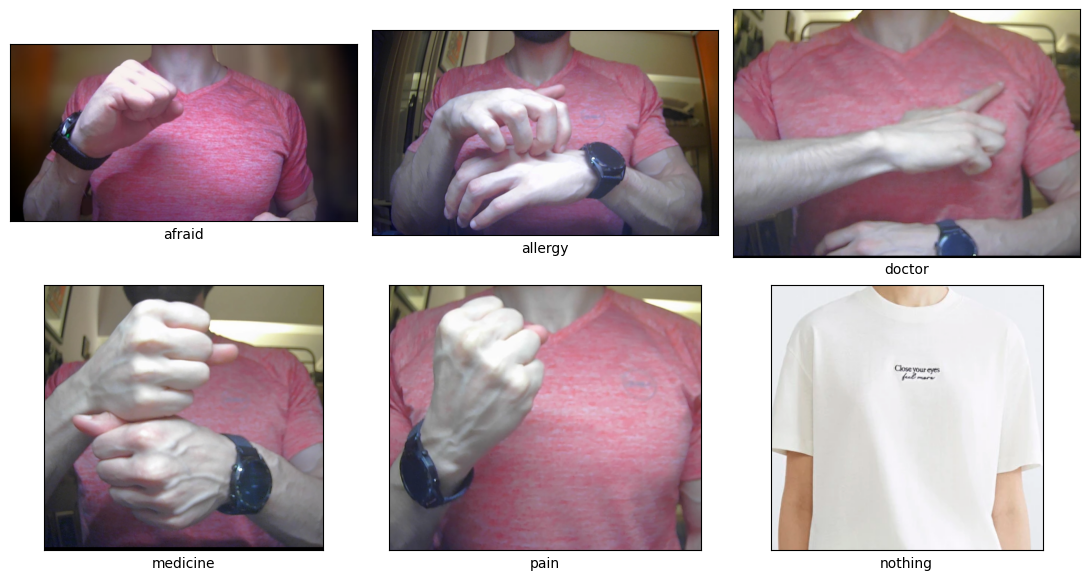

In [3]:
classes = ['afraid', 'allergy', 'doctor', 'medicine', 'pain', 'nothing']
plt.figure(figsize=(11, 6))

for i in range(0, 6):
    plt.subplot(2, 3, i+1)
    plt.xticks([])
    plt.yticks([])

    folder_path = dataset_dir + "/" + classes[i]
    first_image_name = sorted(os.listdir(folder_path))[0]
    path = folder_path + "/" + first_image_name

    img = plt.imread(path)
    plt.imshow(img)
    plt.xlabel(classes[i])

plt.tight_layout()
plt.show()

In [4]:
# we now split the training to validation/testing
x_train_n, x_val, y_train_n, y_val = train_test_split(x_train, y_train, test_size = 0.3, random_state = 1)



### Network 1

- Added small batch size, due to small dataset
- Dropout after the layer with parameters (convolutional) to be more generalized and avoid overfitting
- stride is higher in maxpool because we want to drop weights, where in convolutional we want to extract features
- Steadily increase filter size, to first get more general features and then extract more details
- 1 hidden layer with relative high number of newrons for expiremintation later

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [5]:
seed = 2
tf.random.set_seed(seed)
np.random.seed(seed)

model = Sequential()

# 224x224 x 3 channels, so 150.528 features each image
model.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(224,224,3)))
model.add(MaxPool2D((2,2), strides=2))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model.add(MaxPool2D((2,2), strides=2))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.2))
# we have multiple classes, so sigmoid cannot be used
model.add(Dense(len(classes), activation="softmax"))

# power of two to utilize as much memory due to how computers work
# and small, because the dataset is not very large
batch_size = 64
epochs = 200
model_path_one = f'best_model1.h5'
save_model = ModelCheckpoint(model_path_one, save_best_only=True, monitor='val_loss', mode='min', verbose=2)
early_stop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
# shuffle to true to check more data, maybe the model does not see ever let's say doctor
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_1 = model.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle=True, validation_data=(x_val, y_val), callbacks=[save_model, early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2500 - loss: 1.7916
Epoch 1: val_loss improved from None to 19.19151, saving model to best_model1.h5



Epoch 1: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.2500 - loss: 1.7916 - val_accuracy: 0.4000 - val_loss: 19.1915
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3125 - loss: 27.3576
Epoch 2: val_loss did not improve from 19.19151
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.3125 - loss: 27.3576 - val_accuracy: 0.0000e+00 - val_loss: 21.3118
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.2188 - loss: 27.1049
Epoch 3: val_loss improved from 19.19151 to 15.78213, saving model to best_model1.h5



Epoch 3: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.2188 - loss: 27.1049 - val_accuracy: 0.1333 - val_loss: 15.7821
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.1875 - loss: 26.6733
Epoch 4: val_loss improved from 15.78213 to 6.46090, saving model to best_model1.h5



Epoch 4: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 0.1875 - loss: 26.6733 - val_accuracy: 0.4000 - val_loss: 6.4609
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2500 - loss: 14.2146
Epoch 5: val_loss improved from 6.46090 to 4.26254, saving model to best_model1.h5


...


Epoch 39: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.8750 - loss: 0.1949 - val_accuracy: 0.8667 - val_loss: 0.2711
Epoch 40/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 1.0000 - loss: 0.0120
Epoch 40: val_loss did not improve from 0.27109
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 0.8667 - val_loss: 0.2957
Epoch 41/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9688 - loss: 0.1522
Epoch 41: val_loss did not improve from 0.27109
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9688 - loss: 0.1522 - val_accuracy: 0.8667 - val_loss: 0.3136
Epoch 42/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9375 - loss: 0.1461
Epoch 42: val_loss improved from 0.27109 to 0.14888, saving model to best_model1.h5



Epoch 42: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step - accuracy: 0.9375 - loss: 0.1461 - val_accuracy: 0.9333 - val_loss: 0.1489
Epoch 43/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 0.0131
Epoch 43: val_loss improved from 0.14888 to 0.13085, saving model to best_model1.h5



Epoch 43: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step - accuracy: 1.0000 - loss: 0.0131 - val_accuracy: 0.9333 - val_loss: 0.1308
Epoch 44/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 1.0000 - loss: 0.0101
Epoch 44: val_loss did not improve from 0.13085
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 0.0101 - val_accuracy: 0.9333 - val_loss: 0.1887
Epoch 45/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9062 - loss: 0.1795
Epoch 45: val_loss did not improve from 0.13085
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.9062 - loss: 0.1795 - val_accuracy: 0.9333 - val_loss: 0.1483
Epoch 46/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9688 - loss: 0.0564
Epoch 46: val_loss improved from 0.13085 to 0.10887, saving model to best_model1.h5



Epoch 46: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step - accuracy: 0.9688 - loss: 0.0564 - val_accuracy: 0.9333 - val_loss: 0.1089
Epoch 47/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 1.0000 - loss: 0.0067
Epoch 47: val_loss did not improve from 0.10887
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 0.8000 - val_loss: 0.2819
Epoch 48/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9688 - loss: 0.0520
Epoch 48: val_loss did not improve from 0.10887
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.9688 - loss: 0.0520 - val_accuracy: 0.6000 - val_loss: 0.5865
Epoch 49/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9062 - loss: 0.3195
Epoch 49: val_loss did not improve from 0.10887
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.9062 - loss: 0.3195 - val_accuracy: 0.8667 - val_loss: 0.2378
Epoch 50/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 1.0000 - loss: 0.0022
Epoch 50: val_loss did 


Epoch 61: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 22s 22s/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9333 - val_loss: 0.1071
Epoch 62/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 9.0643e-04
Epoch 62: val_loss did not improve from 0.10709
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 9.0643e-04 - val_accuracy: 0.9333 - val_loss: 0.1147
Epoch 63/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 1.0000 - loss: 8.1114e-04
Epoch 63: val_loss did not improve from 0.10709
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 8.1114e-04 - val_accuracy: 0.9333 - val_loss: 0.1249
Epoch 64/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 1.0000 - loss: 0.0271
Epoch 64: val_loss did not improve from 0.10709
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 1.0000 - loss: 0.0271 - val_accuracy: 0.9333 - val_loss: 0.1148
Epoch 65/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 1.0000 - loss: 0.0017
Epoch 6

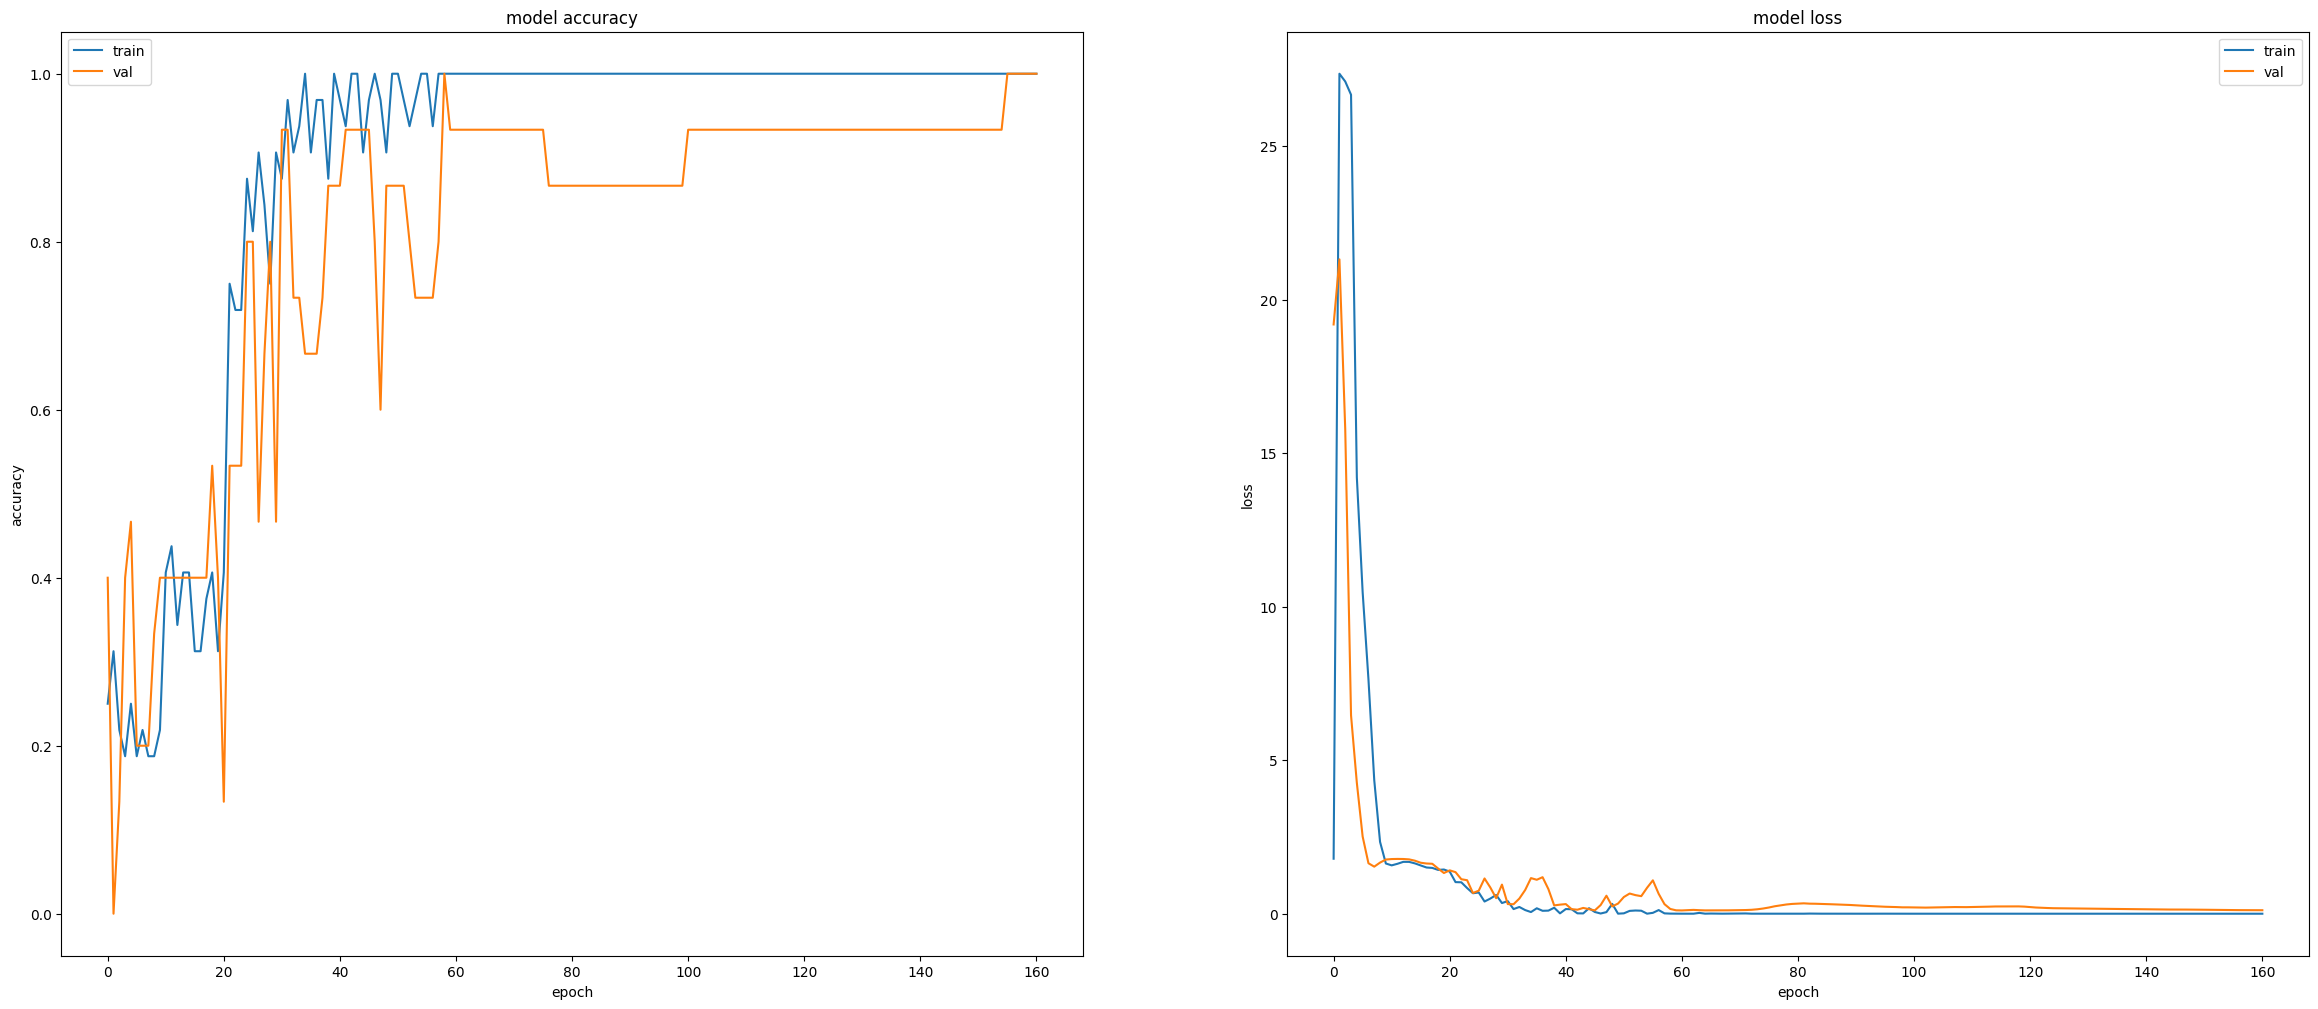

In [6]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

In [14]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
Accuracy: 0.9523809523809523
Recal: 0.8333333333333334
F1: <function f1_score at 0x7b03a10e8680>
Precision: 0.7999999999999999


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


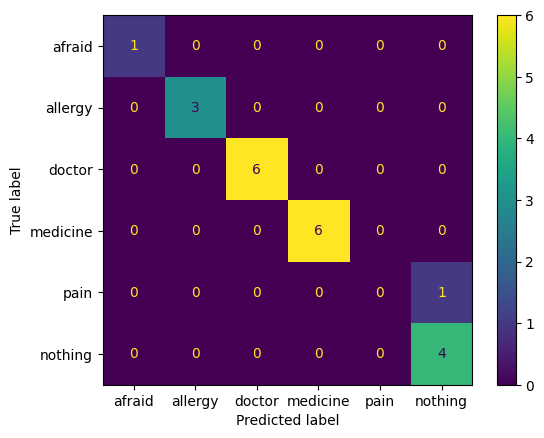

In [7]:
history_1.model.load_weights('best_model1.h5')

predictions=history_1.model.predict(x_test)

y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1_score}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()

## Network 2

Differences are:
- **BatchNormalization** because we want to avoid *expoding gradients*
- **Different optimizer** (rmsprop) just to see it working without stochastic gradient decent as adam uses combination of both
- **Higher epocs**, with combination of *higher patients* to actually use them

In [20]:
from tensorflow.keras.layers import BatchNormalization

model_two = Sequential()

model_two.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(224,224,3)))
model_two.add(BatchNormalization())
model_two.add(MaxPool2D((2,2), strides=2))
model_two.add(Dropout(0.2))

model_two.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(BatchNormalization())
model_two.add(MaxPool2D((2,2), strides=2))
model_two.add(Dropout(0.2))

model_two.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(BatchNormalization())
model_two.add(MaxPool2D((2,2), strides=2))
model_two.add(Dropout(0.2))

model_two.add(Flatten())
model_two.add(Dense(units=240, activation='relu'))
model_two.add(Dropout(0.2))

model_two.add(Dense(units=120, activation='relu'))
model_two.add(Dropout(0.2))

model_two.add(Dense(units=64, activation='relu'))
model_two.add(Dropout(0.2))

model_two.add(Dense(len(classes), activation="softmax"))

batch_size = 64
epochs = 300
model_path_two = f'best_model2.h5'
save_model = ModelCheckpoint(model_path_two, save_best_only=True, monitor='val_loss', mode='min', verbose=2)
early_stop = EarlyStopping(monitor='val_loss', patience=200, restore_best_weights=True)

model_two.compile(loss="categorical_crossentropy", optimizer='rmsprop', metrics=["accuracy"])
history_2 = model_two.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle=True, validation_data=(x_val, y_val), callbacks=[save_model, early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.0938 - loss: 3.8614
Epoch 1: val_loss improved from None to 1.72160, saving model to best_model2.h5



Epoch 1: finished saving model to best_model2.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.0938 - loss: 3.8614 - val_accuracy: 0.1333 - val_loss: 1.7216
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.2500 - loss: 58.2700
Epoch 2: val_loss did not improve from 1.72160
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.2500 - loss: 58.2700 - val_accuracy: 0.1333 - val_loss: 1.7353
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.2188 - loss: 27.6964
Epoch 3: val_loss improved from 1.72160 to 1.40550, saving model to best_model2.h5



Epoch 3: finished saving model to best_model2.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step - accuracy: 0.2188 - loss: 27.6964 - val_accuracy: 0.5333 - val_loss: 1.4055
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.2812 - loss: 19.8654
Epoch 4: val_loss did not improve from 1.40550
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.2812 - loss: 19.8654 - val_accuracy: 0.4667 - val_loss: 1.4900
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4375 - loss: 12.9175
Epoch 5: val_loss did not improve from 1.40550
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.4375 - loss: 12.9175 - val_accuracy: 0.1333 - val_loss: 1.9112
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.3750 - loss: 13.0108
Epoch 6: val_loss improved from 1.40550 to 1.31859, saving model to best_model2.h5



Epoch 6: finished saving model to best_model2.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step - accuracy: 0.3750 - loss: 13.0108 - val_accuracy: 0.4000 - val_loss: 1.3186
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4062 - loss: 8.2039
Epoch 7: val_loss did not improve from 1.31859
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4062 - loss: 8.2039 - val_accuracy: 0.4667 - val_loss: 1.3200
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7500 - loss: 2.9104
Epoch 8: val_loss did not improve from 1.31859
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7500 - loss: 2.9104 - val_accuracy: 0.2667 - val_loss: 1.4962
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7188 - loss: 6.0060
Epoch 9: val_loss did not improve from 1.31859
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7188 - loss: 6.0060 - val_accuracy: 0.0667 - val_loss: 1.7364
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8438 - loss: 3.5005
Epoch 10: v

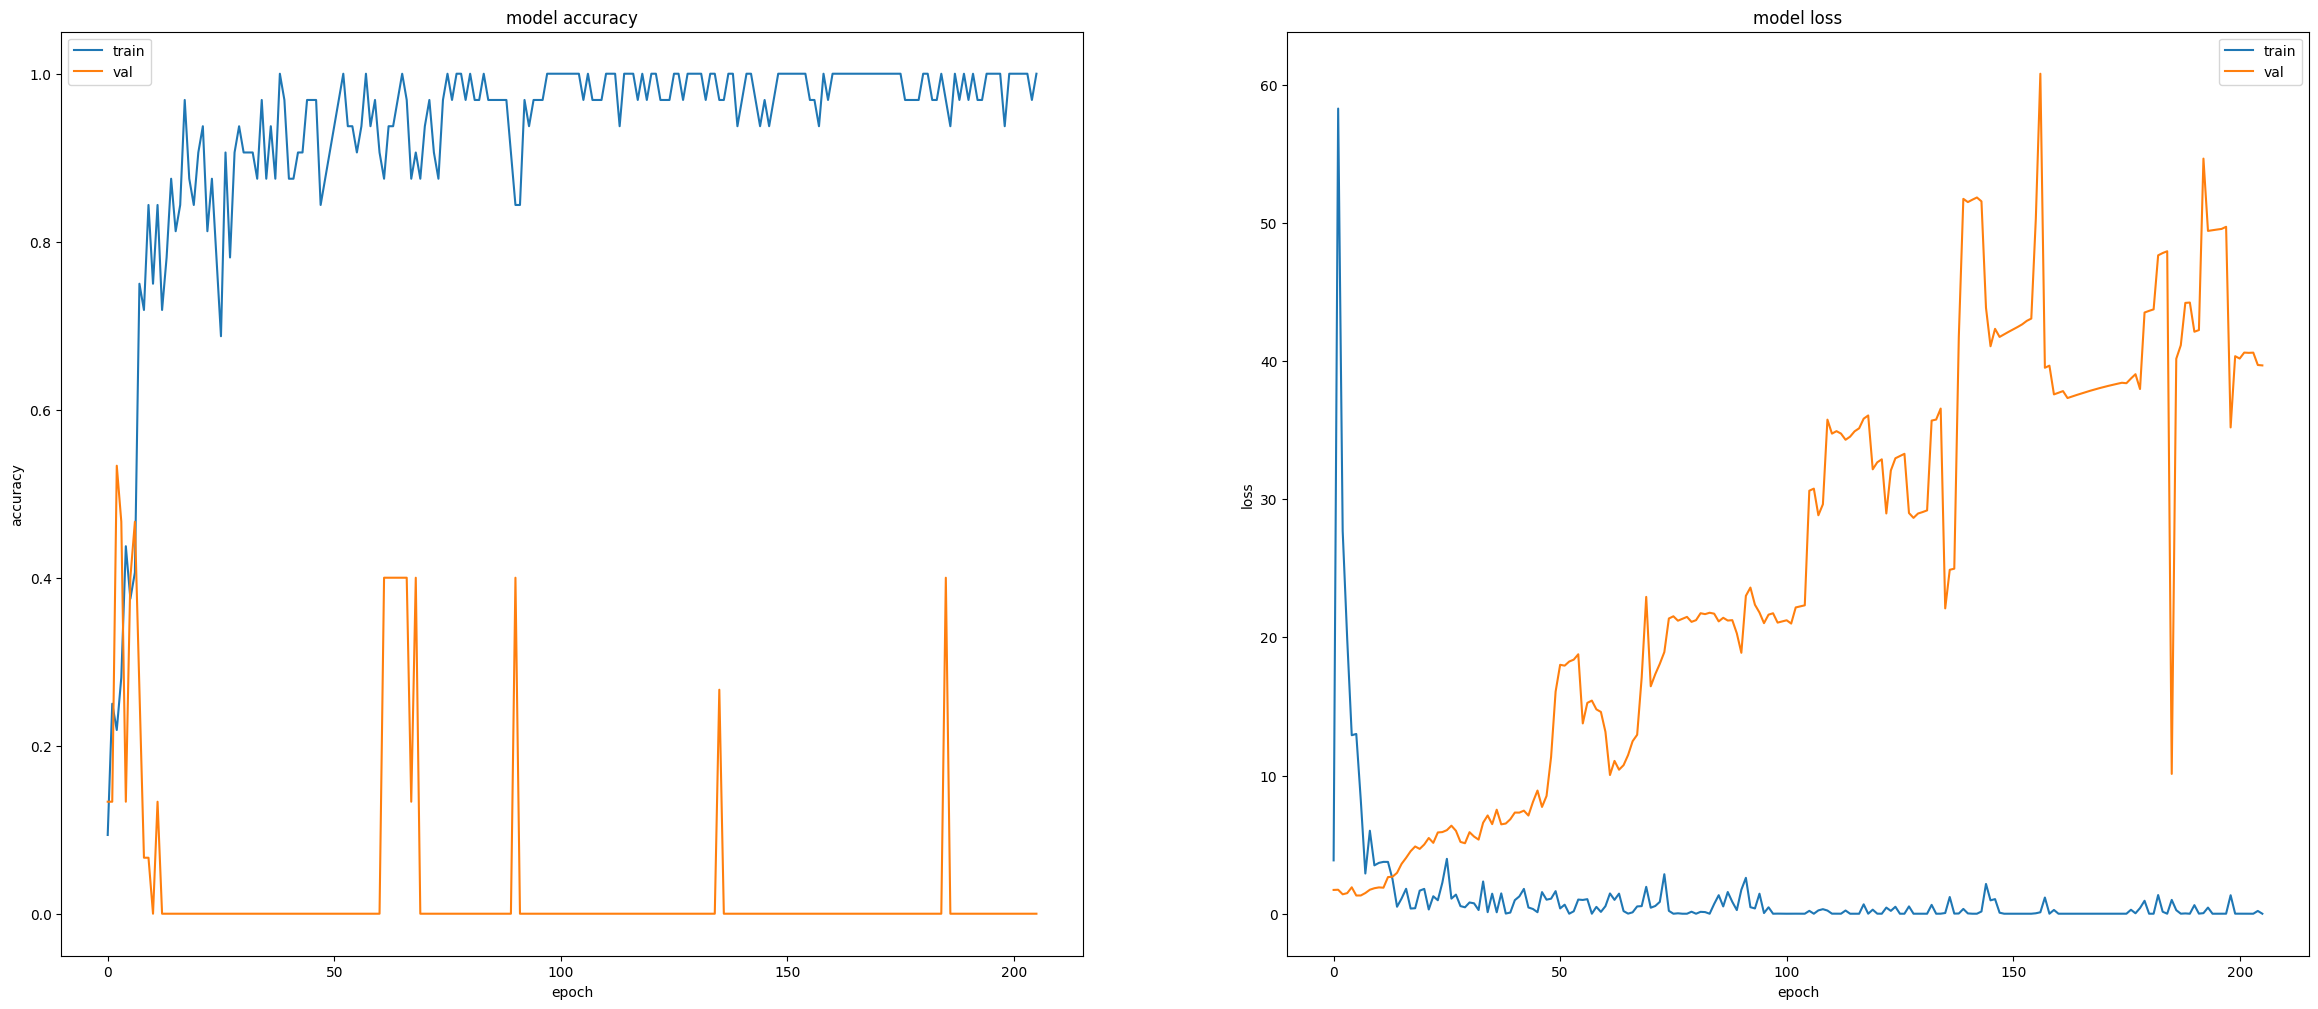

In [21]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Accuracy: 0.38095238095238093
Recal: 0.23611111111111113
F1: <function f1_score at 0x7ee94f70a2a0>
Precision: 0.3333333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


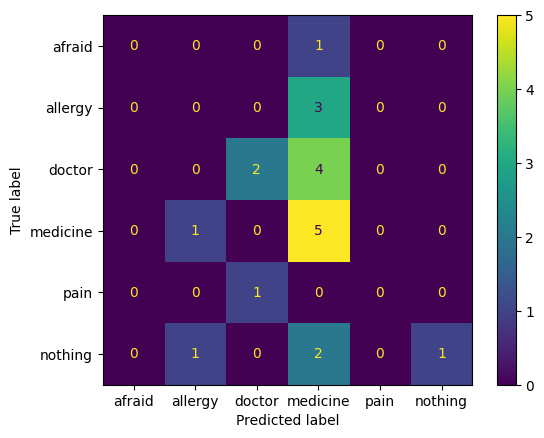

In [24]:
history_2.model.load_weights('best_model2.h5')

predictions2=history_2.model.predict(x_test)

y_pred_classes = np.argmax(predictions2, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1_score}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm2 = confusion_matrix(y_true_classes, y_pred_classes)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=classes)
disp2.plot()

## Network 3

I wanted to use a change in learning rate during training with **exonential decay**. Keras has a different implementation with formula

```
initial_learning_rate * decay_rate ^ (step / decay_steps)
```

so when we set staircase=False, the decayed learning rate follows a continuous exponential decay curve
- because step = t, that increases by 1 and decay_steps = 1, t is only left in the equation
- decay_rate = e^-k

so we have the theory type:
```
λ0*e^-k*t
```

also leave the patience a little higher

In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from keras.optimizers import SGD

k = 0.00001

lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=1,
    decay_rate=np.exp(-k),
    staircase=False
)

model_three = Sequential()

model_three.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(224,224,3)))
model_three.add(BatchNormalization())
model_three.add(MaxPool2D((2,2), strides=2))
model_three.add(Dropout(0.2))

model_three.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu'))
model_three.add(BatchNormalization())
model_three.add(MaxPool2D((2,2), strides=2))
model_three.add(Dropout(0.2))

model_three.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu'))
model_three.add(BatchNormalization())
model_three.add(MaxPool2D((2,2), strides=2))
model_three.add(Dropout(0.2))

model_three.add(Flatten())
model_three.add(Dense(units=240, activation='relu'))
model_three.add(Dropout(0.2))

model_three.add(Dense(units=120, activation='relu'))
model_three.add(Dropout(0.2))

model_three.add(Dense(units=64, activation='relu'))
model_three.add(Dropout(0.2))

model_three.add(Dense(len(classes), activation="softmax"))

batch_size = 64
epochs = 300
model_path_three = f'best_model3.h5'
save_model = ModelCheckpoint(model_path_three, save_best_only=True, monitor='val_loss', mode='min', verbose=2)
early_stop = EarlyStopping(monitor='val_loss', patience=220, restore_best_weights=True)

model_three.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=lr_schedule), metrics=["accuracy"])
history_3 = model_three.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle=True, validation_data=(x_val, y_val), callbacks=[save_model, early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.1875 - loss: 2.7894
Epoch 1: val_loss improved from None to 1.75203, saving model to best_model3.h5



Epoch 1: finished saving model to best_model3.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.1875 - loss: 2.7894 - val_accuracy: 0.4000 - val_loss: 1.7520
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.2500 - loss: 2.7595
Epoch 2: val_loss did not improve from 1.75203
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.2500 - loss: 2.7595 - val_accuracy: 0.4000 - val_loss: 1.7580
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.2812 - loss: 2.6826
Epoch 3: val_loss did not improve from 1.75203
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.2812 - loss: 2.6826 - val_accuracy: 0.4000 - val_loss: 1.7636
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2500 - loss: 2.2202
Epoch 4: val_loss did not improve from 1.75203
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.2500 - loss: 2.2202 - val_accuracy: 0.4000 - val_loss: 1.7666
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3125 - loss: 1.8519
Epoch 5: val_los

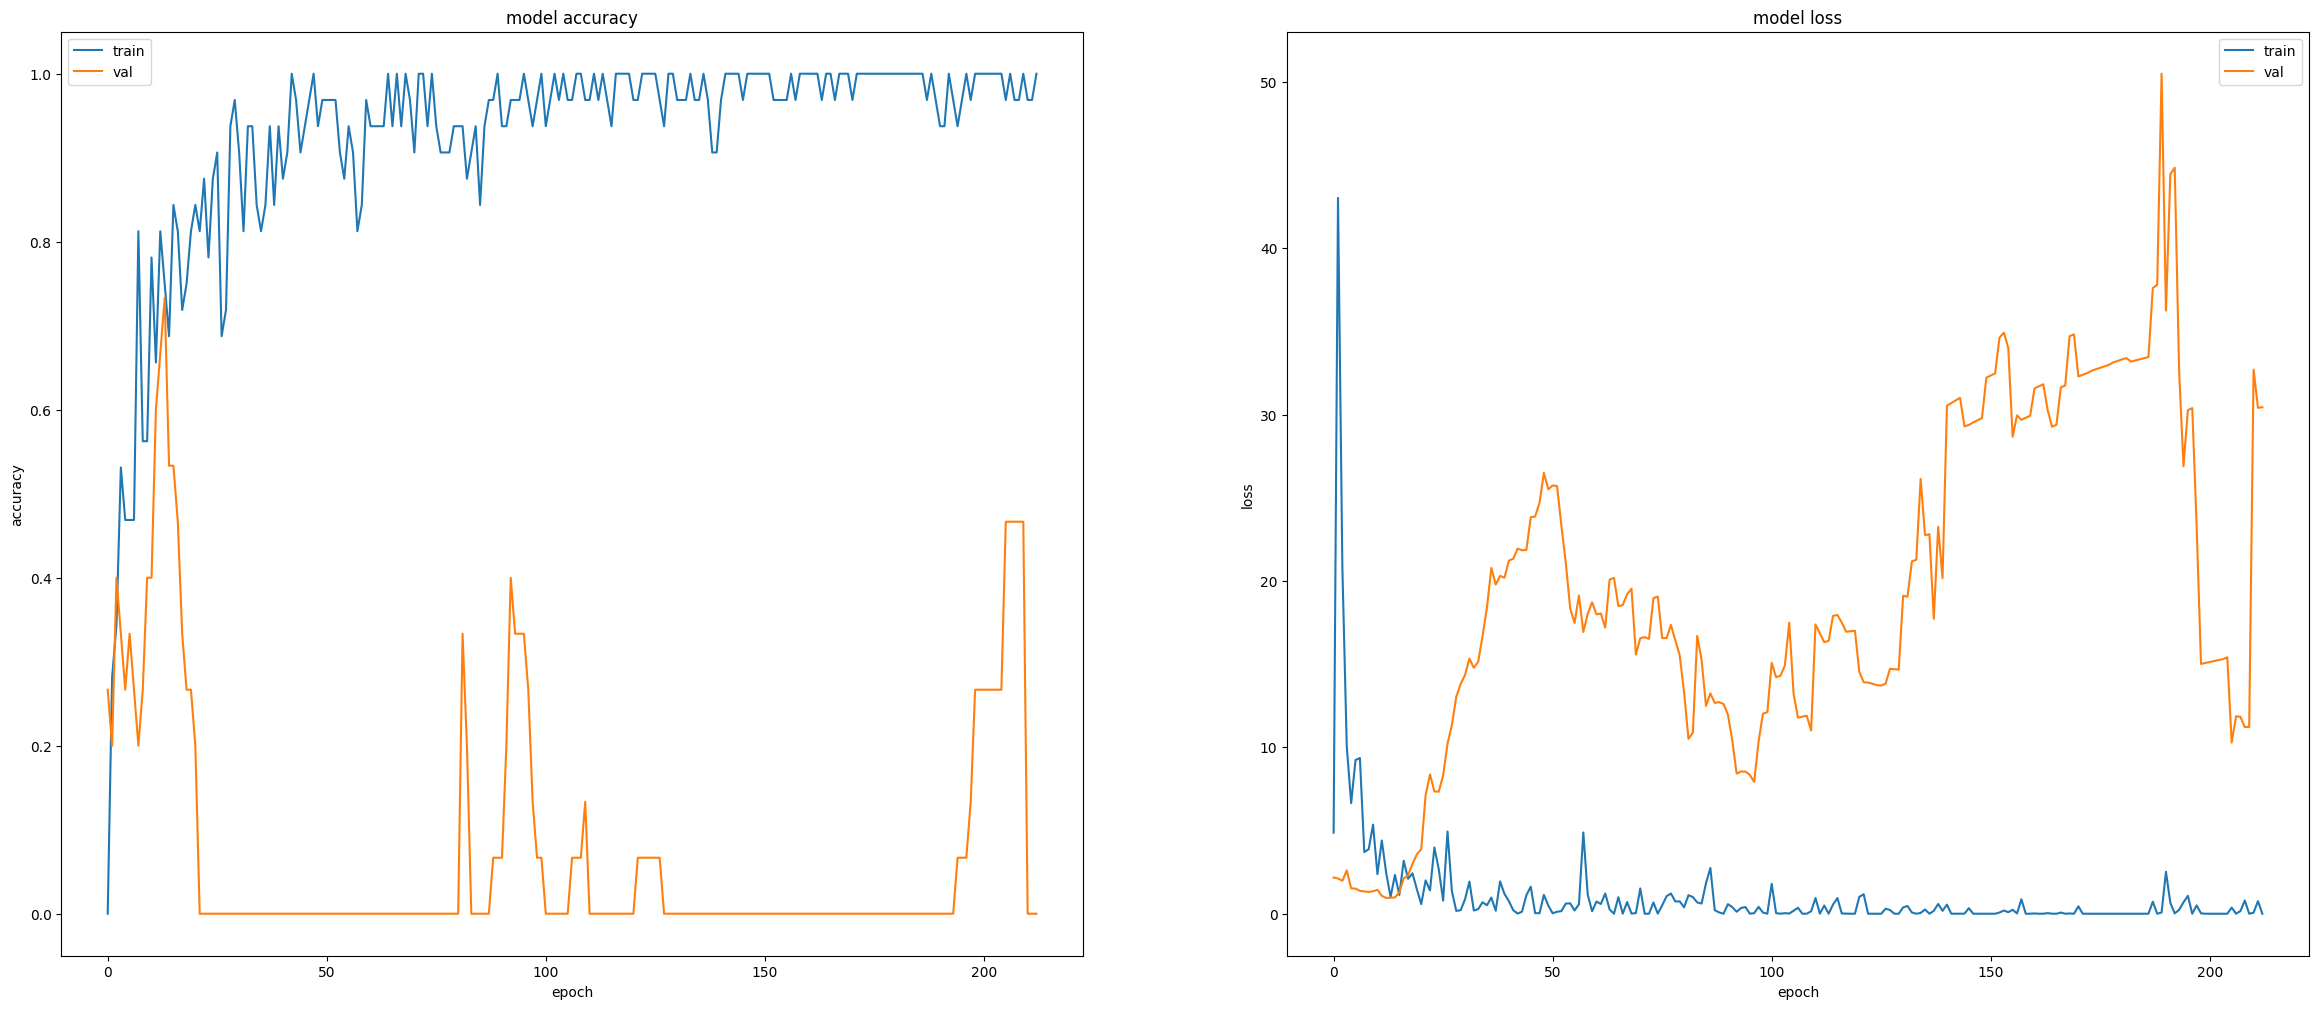

In [ ]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

In [ ]:
history_3.model.load_weights('best_model3.h5')

predictions3=history_3.model.predict(x_test)

y_pred_classes = np.argmax(predictions3, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1_score}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm3 = confusion_matrix(y_true_classes, y_pred_classes)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=classes)
disp3.plot()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Accuracy: 0.7142857142857143
Recal: 0.48611111111111116
F1: <function f1_score at 0x7ee94f70a2a0>
Precision: 0.548611111111111


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
